<a href="https://colab.research.google.com/github/Pranesh-M-2006/Mechine-learning/blob/main/Exp%203/Scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Roll No: 23AIXXX  (Replace with your roll number)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [3]:
# Encode parental education level
df['parental level of education'] = df['parental level of education'].astype('category').cat.codes

# Encode test preparation course (completed = 1, none = 0)
df['test preparation course'] = df['test preparation course'].map({'completed':1, 'none':0})


In [4]:
df['Final_Score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3


In [5]:
np.random.seed(42)
df['Study_Hours'] = np.random.randint(1, 6, size=len(df))
df['Attendance_%'] = np.random.randint(60, 100, size=len(df))
df['Sleep_Hours'] = np.random.randint(4, 9, size=len(df))


In [6]:
features = [
    'Study_Hours',
    'Attendance_%',
    'parental level of education',
    'test preparation course',
    'Sleep_Hours'
]

X = df[features]
y = df['Final_Score']


In [7]:
X = X.fillna(X.median())


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [11]:
y_pred = model.predict(X_test)


In [12]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 210.19254305293808
RMSE: 14.498018590584648
R2 Score: 0.019471430077149465


In [13]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(coefficients)


                       Feature  Coefficient
0                  Study_Hours     0.243139
1                 Attendance_%    -0.380586
2  parental level of education    -1.012143
3      test preparation course     3.875929
4                  Sleep_Hours    -0.334296


In [14]:
important_features = coefficients[
    abs(coefficients['Coefficient']) > 0.1
]['Feature']

print("Selected Features:", important_features)


Selected Features: 0                    Study_Hours
1                   Attendance_%
2    parental level of education
3        test preparation course
4                    Sleep_Hours
Name: Feature, dtype: object


In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
print("Ridge R2:", r2_score(y_test, ridge_pred))


Ridge R2: 0.019522219278421016


In [16]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
print("Lasso R2:", r2_score(y_test, lasso_pred))


Lasso R2: 0.02319604345458659


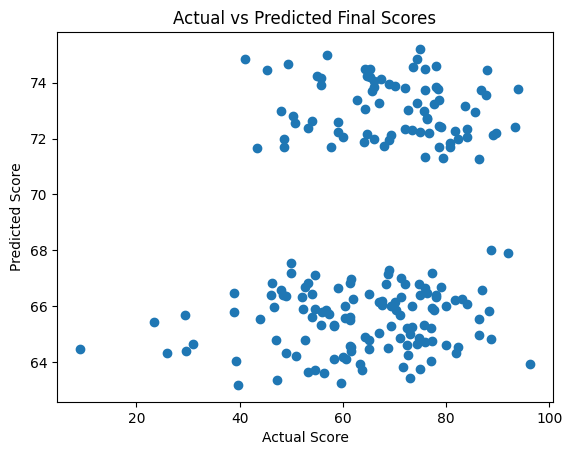

In [17]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Final Scores")
plt.show()


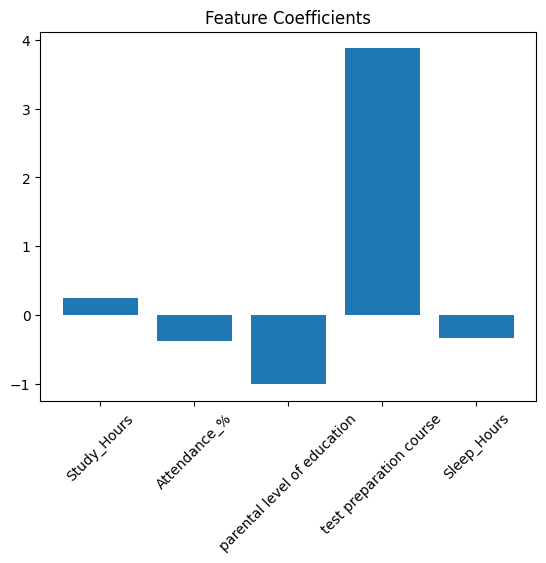

In [18]:
plt.figure()
plt.bar(features, model.coef_)
plt.xticks(rotation=45)
plt.title("Feature Coefficients")
plt.show()


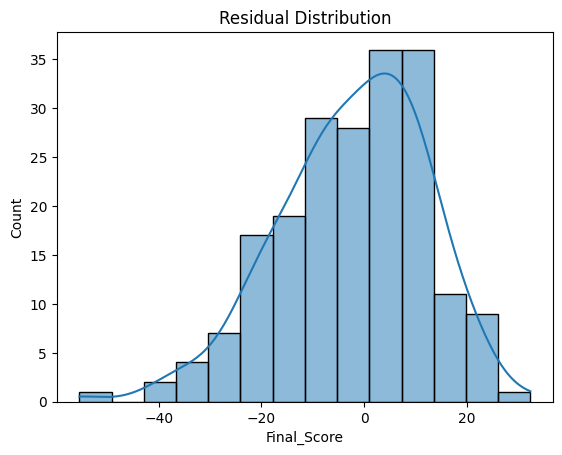

In [19]:
residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()
